# Arabesque: School Style Analysis 2012-2026

This notebook re-runs the school-style arabesque analysis on `Data/arabesque_531.csv`.

Rules for this notebook:
- Only rows with a non-empty `school_style` are analyzed.
- `school_style` is treated as the ballet school/style label.
- All visual results are drawn directly inside notebook cells with `matplotlib`.
- The method follows the style/geometry analysis logic of `arabesque_analysis.ipynb`: summarize style groups, compare geometry metrics, inspect decade patterns, and test whether decade still matters after controlling for style.

## How to Read the Boxplots

In the boxplots below:

- The **box** runs from Q1 to Q3, meaning the middle 50% of observations.
- The **vertical line inside the box** is the median.
- The **thin horizontal line** shows the broader non-outlier range.

If the median line is very far to one side of the box, that usually means the data are **skewed**. For example, many dancers may cluster near the lower values, while a few higher values stretch Q3 or the upper whisker. This is normal for uneven, small, or skewed samples. It does not mean the chart is broken.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_DIR = Path(r"D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main")
INPUT_CSV = PROJECT_DIR / "Data" / "arabesque_531.csv"
OUTPUT_DIR = PROJECT_DIR / "arabesque_531_school_style_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STYLE_ORDER = ["Vaganova", "French", "RAD", "Balanchine", "Mixed"]
STYLE_COLORS = {
    "Vaganova": "#2f7d3b",
    "French": "#b33443",
    "RAD": "#7d56a0",
    "Balanchine": "#e1812c",
    "Mixed": "#59c3c3",
}

METRIC_LABELS = {
    "split_angle": "Split angle",
    "torso_tilt": "Torso tilt",
    "support_leg_plumb": "Support-leg plumb",
    "arabesque_angle": "Leg-torso angle",
    "pelvic_tilt_angle": "Pelvic tilt angle",
    "shoulder_hip_torsion": "Shoulder-hip torsion",
}

METRIC_SUBTITLES = {
    "split_angle": "two-leg extension",
    "torso_tilt": "neck-pelvis vs vertical",
    "support_leg_plumb": "support leg vs vertical",
    "arabesque_angle": "neck-pelvis vs raised leg",
    "pelvic_tilt_angle": "pelvis orientation",
    "shoulder_hip_torsion": "shoulders vs hips twist",
}

GEOMETRY_FEATURES = ["torso_tilt", "split_angle", "support_leg_plumb", "pelvic_tilt_angle", "shoulder_hip_torsion"]
STYLE_ANALYSIS_FEATURES = ["arabesque_angle", *GEOMETRY_FEATURES]

print(INPUT_CSV)
print(OUTPUT_DIR)

D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main\Data\arabesque_531.csv
D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main\arabesque_531_school_style_results


## 1. Load and Filter Data

In [2]:
raw = pd.read_csv(INPUT_CSV)
print(f"Original rows: {len(raw)}")

df = raw.copy()
df["school_style"] = df["school_style"].astype("string").str.strip()
df = df[df["school_style"].notna() & (df["school_style"] != "")].copy()
df = df[df["school_style"].isin(STYLE_ORDER)].copy()

for col in STYLE_ANALYSIS_FEATURES + ["year", "decade", "raised_knee_angle", "support_knee_angle"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=STYLE_ANALYSIS_FEATURES + ["school_style"]).copy()
df["school_style"] = pd.Categorical(df["school_style"], STYLE_ORDER, ordered=True)

print(f"Rows with school_style and complete core metrics: {len(df)}")
style_counts_total = df["school_style"].value_counts().reindex(STYLE_ORDER).dropna().astype(int)
display(style_counts_total.rename_axis("school_style").reset_index(name="count"))
display(df[["full_name", "year", "decade", "countries", "school_style", *STYLE_ANALYSIS_FEATURES]].head())

df.to_csv(OUTPUT_DIR / "filtered_school_style_rows.csv", index=False)

Original rows: 353
Rows with school_style and complete core metrics: 132


,school_style,count
0,Vaganova,44
1,French,5
2,RAD,12
3,Balanchine,13
4,Mixed,58


,full_name,year,decade,countries,school_style,arabesque_angle,torso_tilt,split_angle,support_leg_plumb,pelvic_tilt_angle,shoulder_hip_torsion
204,Ray Brooke,2012,2010,New Zealand,RAD,94.857122,25.485546,113.284701,6.607257,27.752587,14.183468
205,Caballero Junior Gaspard,2012,2010,Paraguay,Vaganova,83.371458,15.528547,110.845339,17.981483,36.245238,10.437180
206,Chuvas Thamires,2012,2010,Brazil,Vaganova,97.064872,21.052968,103.798135,7.217369,27.706131,34.606381
207,Maslen Max,2012,2010,United Kingdom,RAD,116.376147,20.539237,77.150044,15.838702,30.128262,7.790742
208,Vinograd Sonia,2012,2010,Spain,Vaganova,105.970549,18.909252,100.434766,32.475329,4.270176,38.704906


## 2. Summary Statistics by School Style

In [3]:
def metric_summary(data: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    rows = []
    for style, group in data.groupby("school_style", observed=True):
        for metric in metrics:
            values = group[metric].dropna()
            rows.append({
                "school_style": style,
                "metric": metric,
                "label": METRIC_LABELS[metric],
                "n": int(values.count()),
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "q1": values.quantile(0.25),
                "median": values.median(),
                "q3": values.quantile(0.75),
                "min": values.min(),
                "max": values.max(),
            })
    return pd.DataFrame(rows)

summary = metric_summary(df, STYLE_ANALYSIS_FEATURES)
summary.to_csv(OUTPUT_DIR / "style_metric_summary.csv", index=False)

median_table = summary.pivot_table(index="school_style", columns="label", values="median", aggfunc="first")
median_table = median_table.reindex(STYLE_ORDER)
display(median_table.round(2))
display(summary.round(3))

label,Leg-torso angle,Pelvic tilt angle,Shoulder-hip torsion,Split angle,Support-leg plumb,Torso tilt
school_style,,,,,,
Vaganova,93.55,28.43,13.60,104.50,11.38,24.00
French,88.21,32.60,5.00,98.06,7.58,31.09
RAD,97.38,30.64,14.86,104.04,9.10,26.27
Balanchine,94.78,32.08,21.34,106.43,11.75,27.73
Mixed,95.36,30.30,16.40,102.69,14.69,25.15


,school_style,metric,label,n,mean,std,q1,median,q3,min,max
0,Vaganova,arabesque_angle,Leg-torso angle,44,92.302,11.311,82.555,93.550,100.712,68.573,113.251
1,Vaganova,torso_tilt,Torso tilt,44,24.813,10.124,18.002,23.998,28.557,5.701,52.192
2,Vaganova,split_angle,Split angle,44,105.555,12.987,100.415,104.499,111.152,77.893,135.447
3,Vaganova,support_leg_plumb,Support-leg plumb,44,13.469,9.436,7.088,11.377,15.640,2.298,37.677
4,Vaganova,pelvic_tilt_angle,Pelvic tilt angle,44,29.343,8.547,25.462,28.431,35.254,4.270,43.488
5,Vaganova,shoulder_hip_torsion,Shoulder-hip torsion,44,16.603,11.953,8.250,13.605,26.045,0.027,50.928
6,French,arabesque_angle,Leg-torso angle,5,97.057,12.679,88.071,88.212,106.748,87.768,114.487
7,French,torso_tilt,Torso tilt,5,29.178,8.269,28.577,31.088,33.967,15.452,36.804
8,French,split_angle,Split angle,5,101.569,8.733,97.606,98.056,106.776,91.583,113.822
9,French,support_leg_plumb,Support-leg plumb,5,12.404,9.699,7.496,7.580,11.532,6.046,29.367


## 3. Main Comparison: Medians and IQRs

This is the cleanest version for comparing school styles. The dot is the median; the thick line is Q1-Q3; the dashed line is the overall median across all rows for that metric.

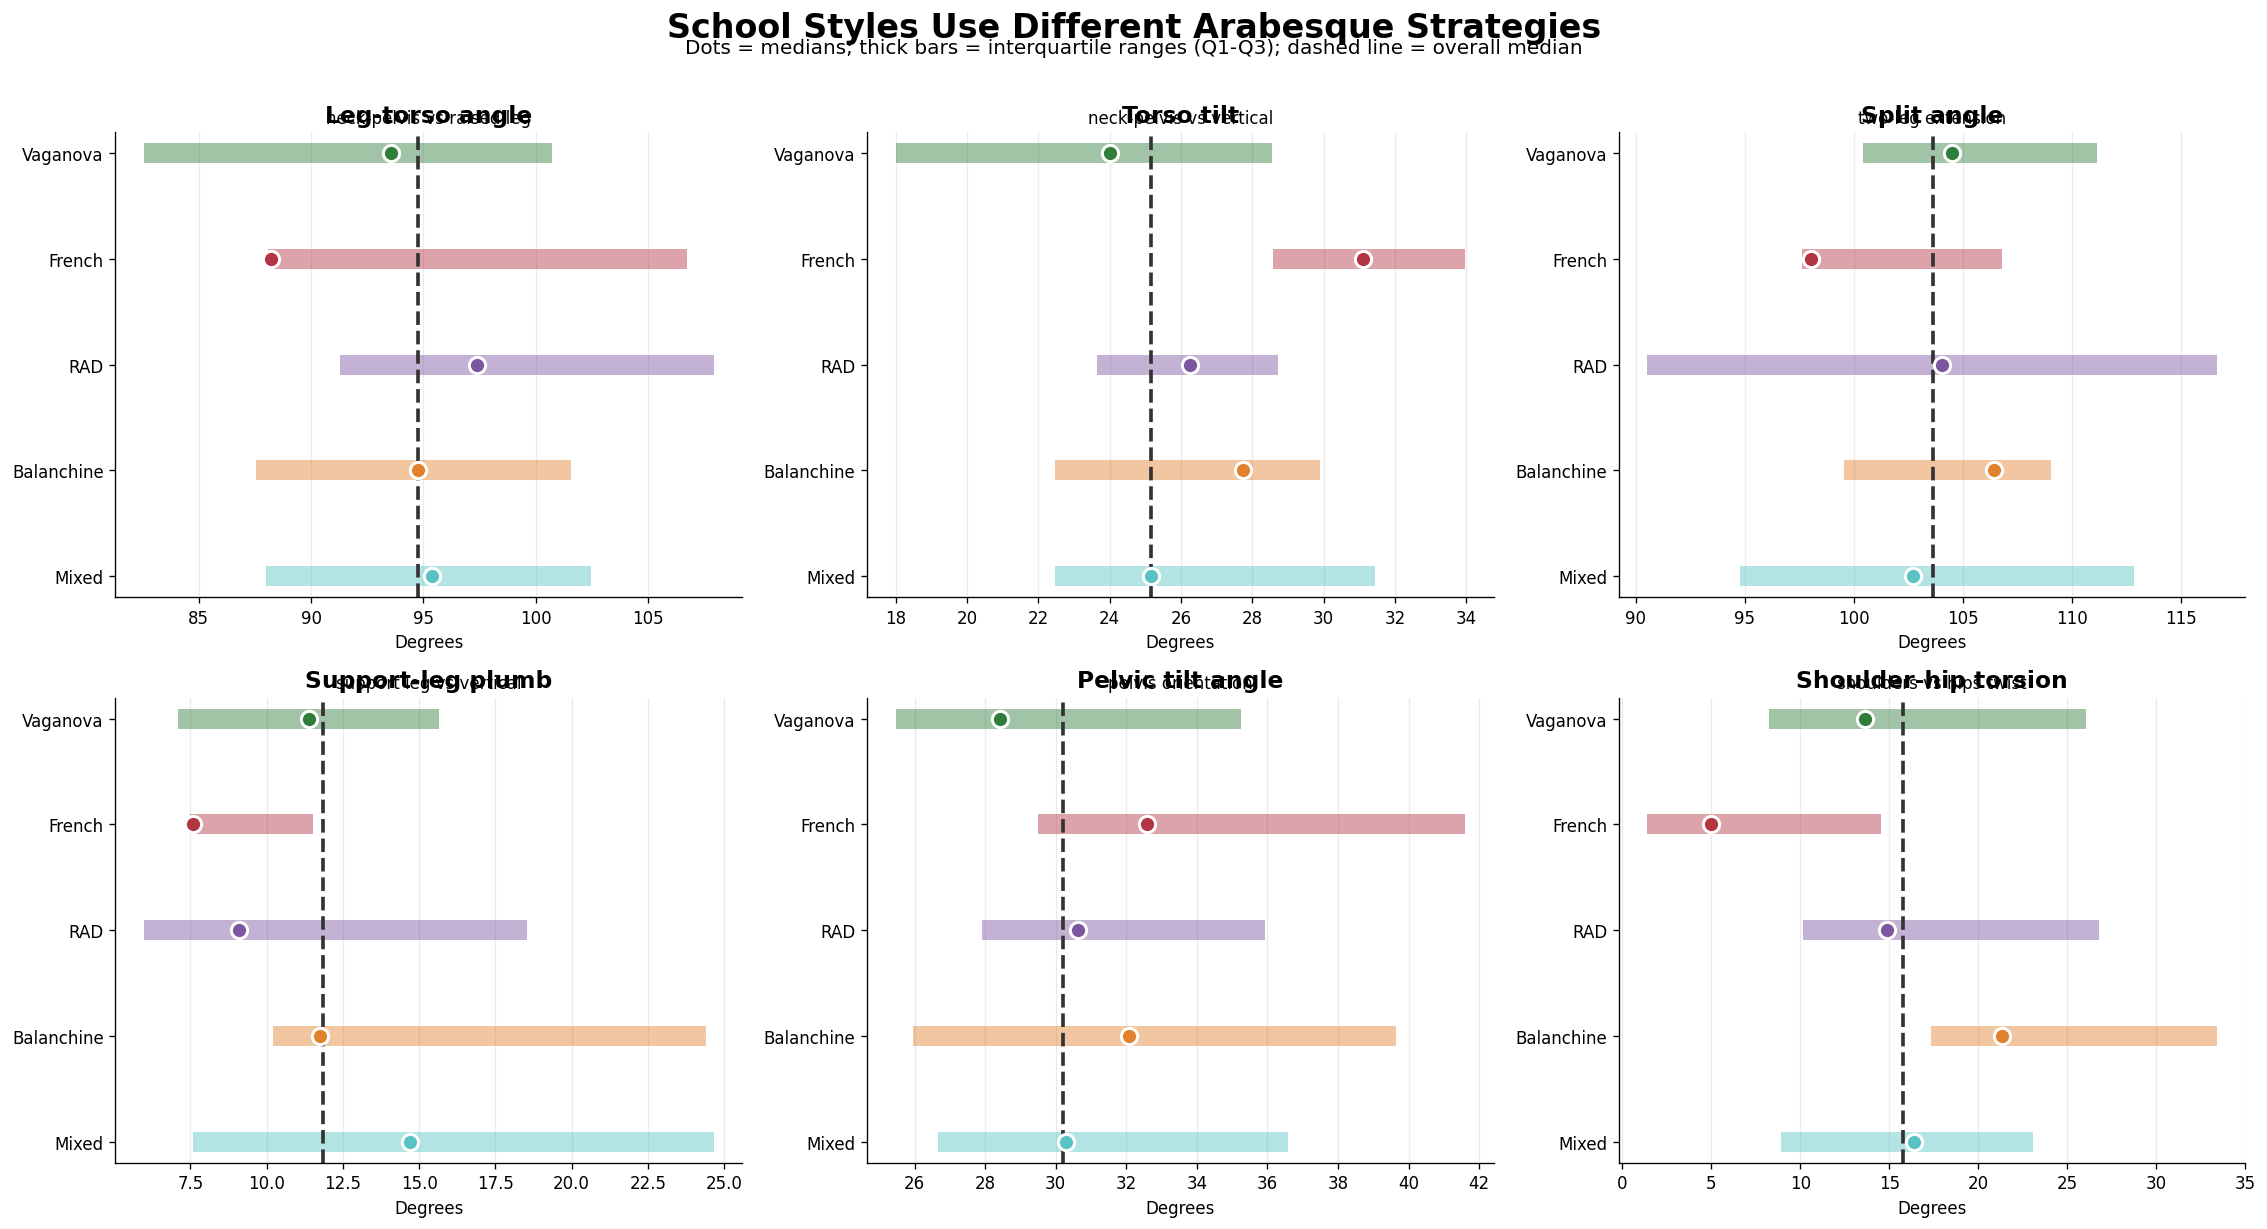

In [4]:
def plot_median_iqr(summary: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(19, 10))
    axes = axes.ravel()

    plot_order = list(reversed(STYLE_ORDER))

    for ax, metric in zip(axes, STYLE_ANALYSIS_FEATURES):
        sub = summary[summary["metric"] == metric].copy()
        sub["school_style"] = pd.Categorical(sub["school_style"], plot_order, ordered=True)
        sub = sub.sort_values("school_style")

        y = np.arange(len(sub))
        for pos, row in zip(y, sub.itertuples(index=False)):
            color = STYLE_COLORS[str(row.school_style)]
            ax.hlines(pos, row.q1, row.q3, color=color, linewidth=12, alpha=0.45)
            ax.scatter(row.median, pos, s=95, color=color, edgecolor="white", linewidth=1.8, zorder=3)

        overall_median = df[metric].median()
        ax.axvline(overall_median, color="#333333", linestyle="--", linewidth=2.2, label="overall median")
        ax.set_yticks(y)
        ax.set_yticklabels(sub["school_style"])
        ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight="bold")
        ax.text(0.5, 1.02, METRIC_SUBTITLES[metric], transform=ax.transAxes, ha="center", fontsize=10)
        ax.set_xlabel("Degrees")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle("School Styles Use Different Arabesque Strategies", fontsize=20, fontweight="bold", y=1.02)
    fig.text(0.5, 0.985, "Dots = medians; thick bars = interquartile ranges (Q1-Q3); dashed line = overall median", ha="center", fontsize=12)
    plt.tight_layout()
    return fig

fig = plot_median_iqr(summary)
fig.savefig(OUTPUT_DIR / "school_style_median_iqr_six_metrics.png", bbox_inches="tight")
plt.show()

## 4. Boxplots

The vertical line inside each horizontal box is the median. If it is off-center, the distribution is skewed. This happens a lot here because some style groups are small, especially French (`n=5`).

C:\Users\lenovo\AppData\Local\Temp\ipykernel_27796\4014206254.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_27796\4014206254.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_27796\4014206254.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)
C:\Users\l

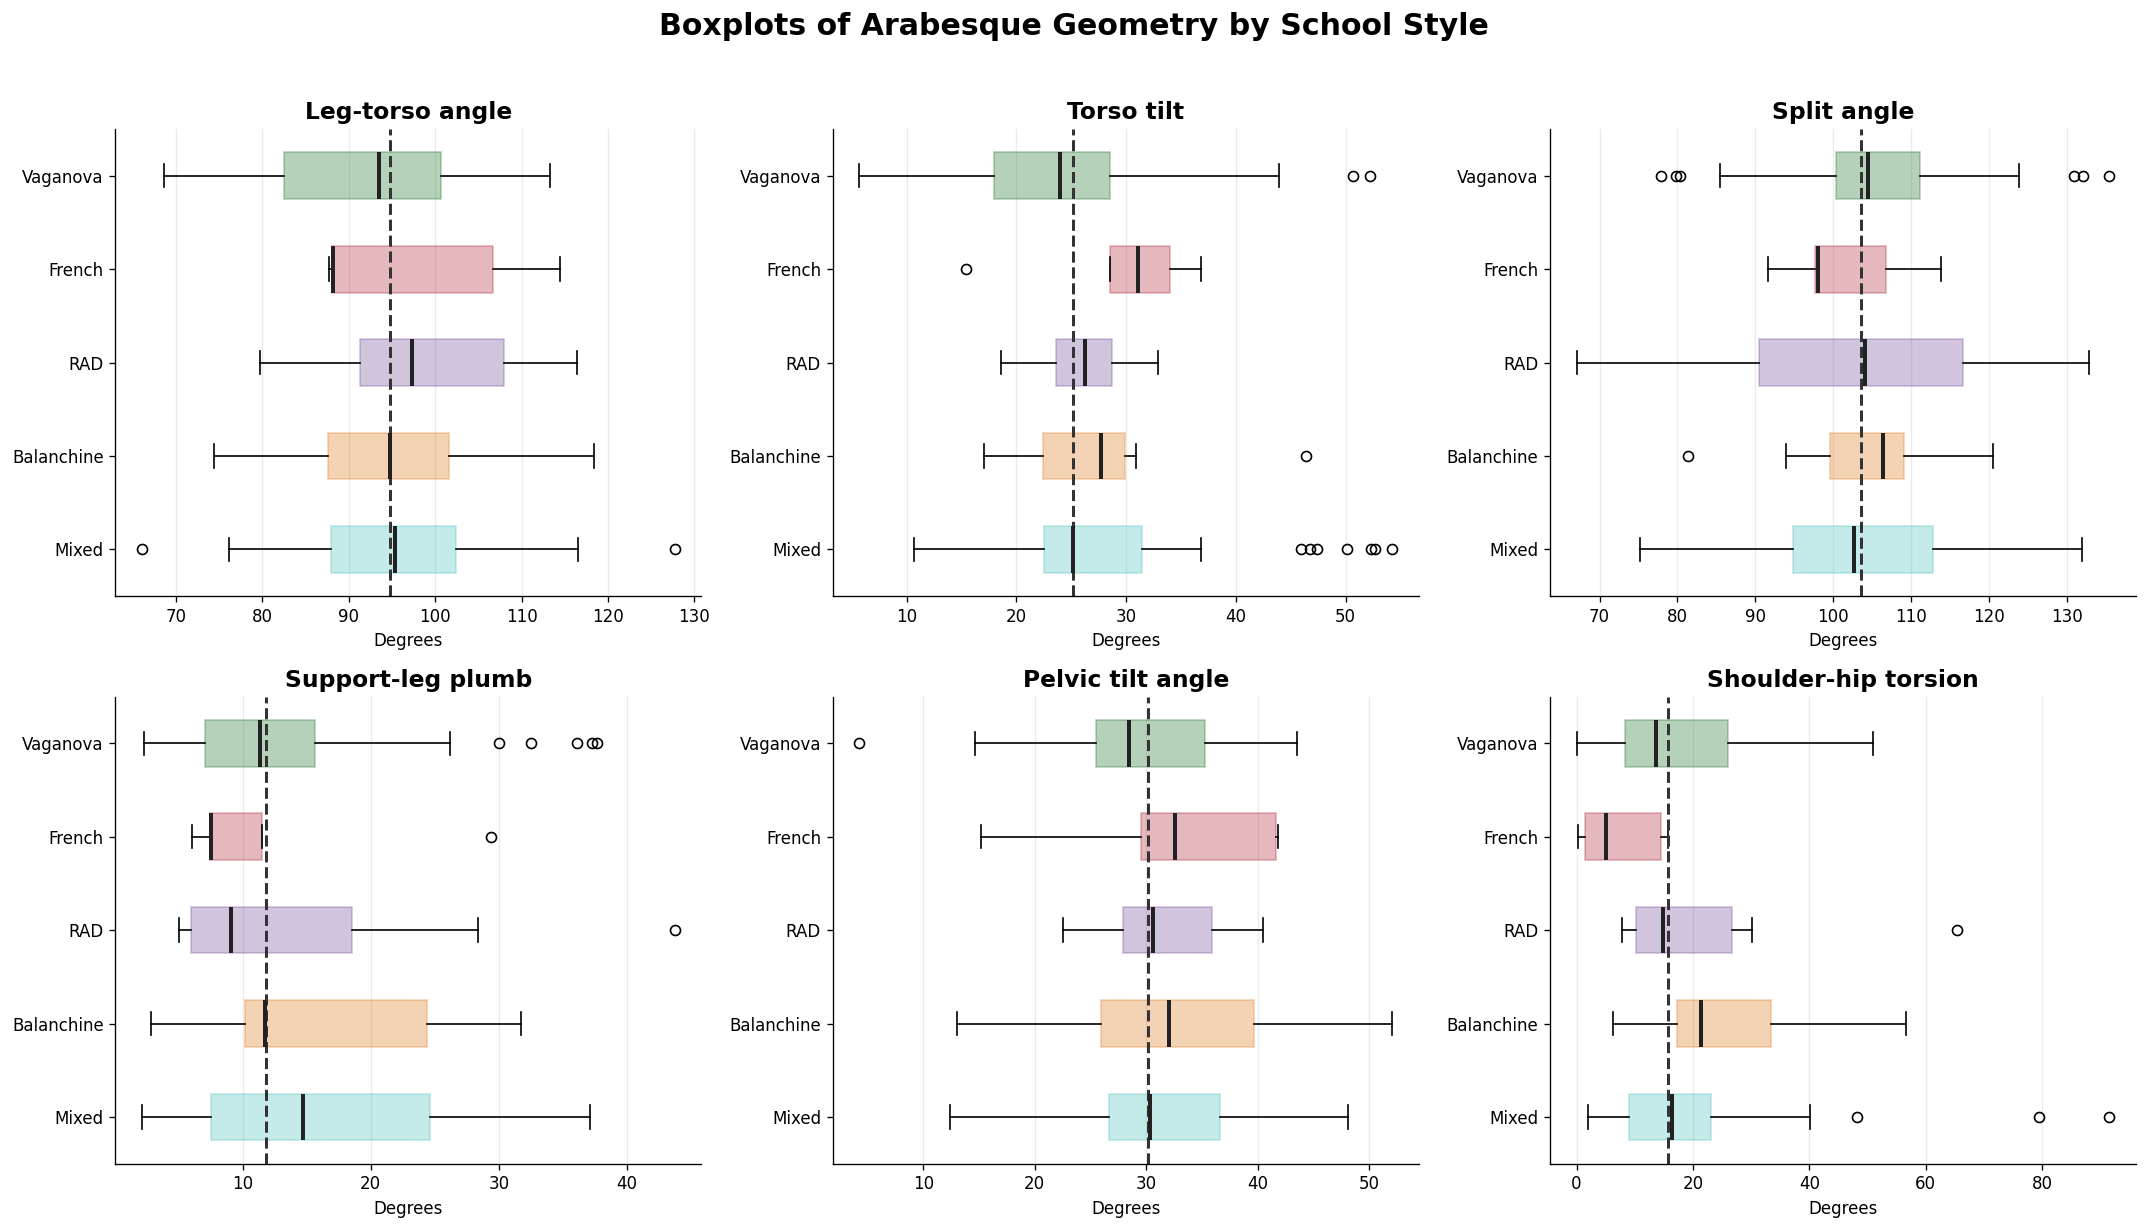

In [5]:
def plot_boxplots(data: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    plot_order = list(reversed(STYLE_ORDER))

    for ax, metric in zip(axes, STYLE_ANALYSIS_FEATURES):
        values = [data.loc[data["school_style"] == style, metric].dropna().to_numpy() for style in plot_order]
        bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)

        for patch, style in zip(bp["boxes"], plot_order):
            patch.set_facecolor(STYLE_COLORS[style])
            patch.set_alpha(0.35)
            patch.set_edgecolor(STYLE_COLORS[style])

        for median in bp["medians"]:
            median.set_color("#222222")
            median.set_linewidth(2.4)

        ax.axvline(data[metric].median(), color="#333333", linestyle="--", linewidth=1.8)
        ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight="bold")
        ax.set_xlabel("Degrees")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle("Boxplots of Arabesque Geometry by School Style", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig

fig = plot_boxplots(df)
fig.savefig(OUTPUT_DIR / "school_style_boxplots_six_metrics.png", bbox_inches="tight")
plt.show()

## 5. School-style Representation by Decade

,decade,school_style,count,proportion
0,2010,Vaganova,21,0.323077
1,2010,French,1,0.015385
2,2010,RAD,8,0.123077
3,2010,Balanchine,5,0.076923
4,2010,Mixed,30,0.461538
5,2020,Vaganova,23,0.343284
6,2020,French,4,0.059701
7,2020,RAD,4,0.059701
8,2020,Balanchine,8,0.119403
9,2020,Mixed,28,0.417910


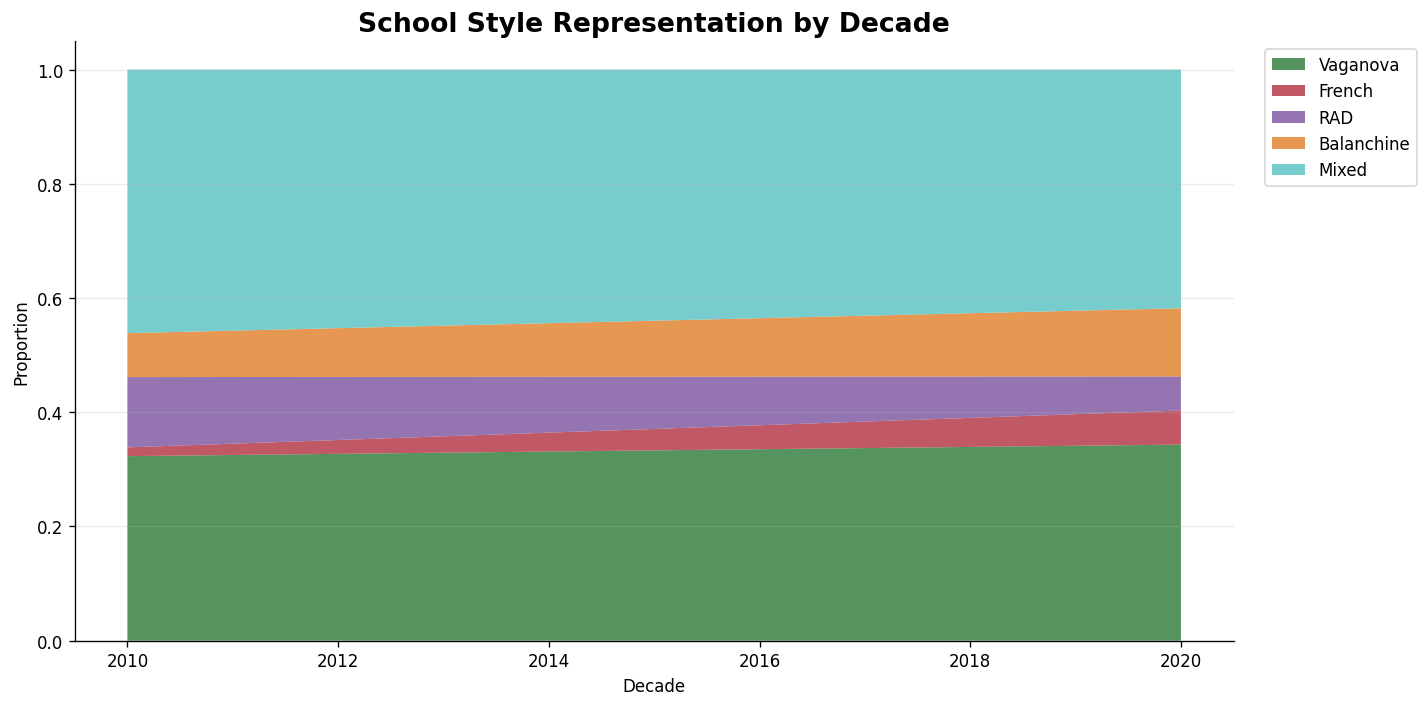

In [6]:
style_counts = (
    df.dropna(subset=["decade"])
    .groupby(["decade", "school_style"], observed=True)
    .size()
    .reset_index(name="count")
)
style_counts["proportion"] = style_counts["count"] / style_counts.groupby("decade")["count"].transform("sum")
style_counts.to_csv(OUTPUT_DIR / "style_representation_by_decade.csv", index=False)
display(style_counts)

pivot_prop = style_counts.pivot(index="decade", columns="school_style", values="proportion").fillna(0)
pivot_prop = pivot_prop.reindex(columns=[s for s in STYLE_ORDER if s in pivot_prop.columns])

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    pivot_prop.index,
    pivot_prop.T,
    labels=pivot_prop.columns,
    colors=[STYLE_COLORS[c] for c in pivot_prop.columns],
    alpha=0.82,
)
ax.set_title("School Style Representation by Decade", fontsize=16, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Proportion")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "school_style_representation_by_decade.png", bbox_inches="tight")
plt.show()

## 6. Style Centroids and Inter-style Distance

A style centroid is the average geometry profile of a style in one decade. Inter-style distance measures how far those style centroids are from one another in the geometry space formed by `torso_tilt`, `split_angle`, `support_leg_plumb`, `pelvic_tilt_angle`, and `shoulder_hip_torsion`.

,decade,school_style,torso_tilt,split_angle,support_leg_plumb,pelvic_tilt_angle,shoulder_hip_torsion
0,2010,Vaganova,21.960,104.389,13.708,26.154,19.425
1,2010,French,36.804,97.606,6.046,29.488,14.537
2,2010,RAD,25.348,102.907,10.430,30.182,25.615
3,2010,Balanchine,25.786,104.367,11.453,23.359,29.278
4,2010,Mixed,25.443,103.650,12.808,30.048,23.012
5,2020,Vaganova,27.417,106.620,13.251,32.255,14.026
6,2020,French,27.271,102.559,13.994,32.791,5.618
7,2020,RAD,27.861,101.796,22.529,33.805,10.759
8,2020,Balanchine,27.325,104.291,17.160,37.762,24.141
9,2020,Mixed,31.086,102.383,21.525,31.899,14.995


,decade,num_styles,mean_distance,median_distance,min_distance,max_distance
0,2010,5,12.178,10.231,3.608,21.242
1,2020,5,11.850,11.728,5.773,19.516


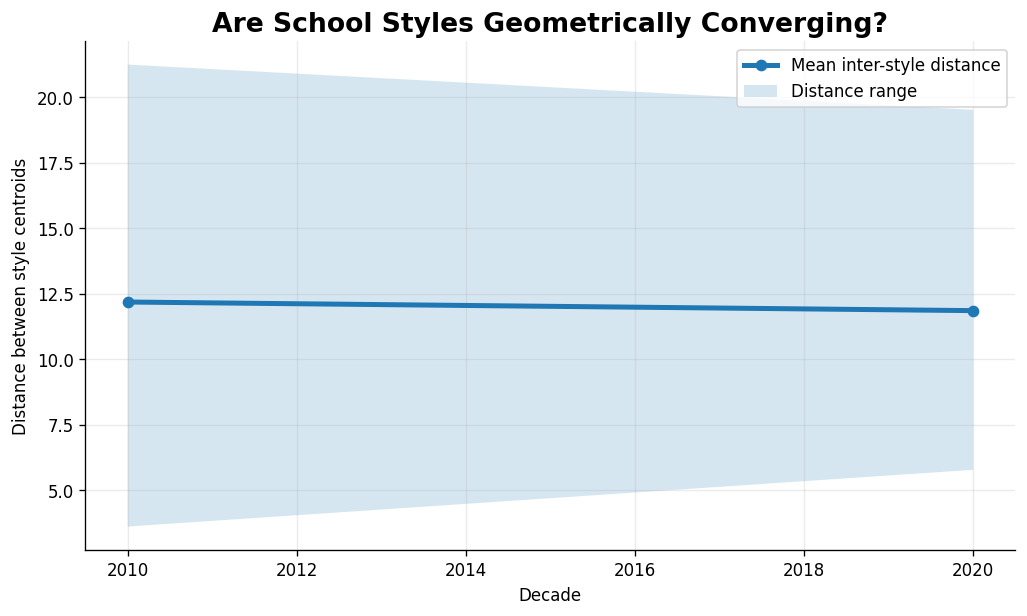

In [7]:
centroids = (
    df.dropna(subset=["decade", *GEOMETRY_FEATURES])
    .groupby(["decade", "school_style"], observed=True)[GEOMETRY_FEATURES]
    .mean()
    .reset_index()
)
centroids.to_csv(OUTPUT_DIR / "style_centroids_by_decade.csv", index=False)
display(centroids.round(3))

def summarize_pairwise_distances(centroid_df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []
    for decade in sorted(centroid_df["decade"].dropna().unique()):
        sub = centroid_df[centroid_df["decade"] == decade].dropna(subset=features)
        if len(sub) < 2:
            continue
        matrix = sub[features].to_numpy(dtype=float)
        distances = []
        for i in range(len(matrix)):
            for j in range(i + 1, len(matrix)):
                distances.append(float(np.linalg.norm(matrix[i] - matrix[j])))
        distances = np.array(distances)
        rows.append({
            "decade": decade,
            "num_styles": len(sub),
            "mean_distance": np.mean(distances),
            "median_distance": np.median(distances),
            "min_distance": np.min(distances),
            "max_distance": np.max(distances),
        })
    return pd.DataFrame(rows)

distance_df = summarize_pairwise_distances(centroids, GEOMETRY_FEATURES)
distance_df.to_csv(OUTPUT_DIR / "inter_style_distances_by_decade.csv", index=False)
display(distance_df.round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
if not distance_df.empty:
    ax.plot(distance_df["decade"], distance_df["mean_distance"], marker="o", linewidth=3, label="Mean inter-style distance")
    ax.fill_between(distance_df["decade"], distance_df["min_distance"], distance_df["max_distance"], alpha=0.18, label="Distance range")
    ax.set_title("Are School Styles Geometrically Converging?", fontsize=16, fontweight="bold")
    ax.set_xlabel("Decade")
    ax.set_ylabel("Distance between style centroids")
    ax.grid(alpha=0.25)
    ax.legend()
fig.savefig(OUTPUT_DIR / "inter_style_distance_by_decade.png", bbox_inches="tight")
plt.show()

## 7. Regression: Does Decade Still Matter After Controlling for School Style?

This reproduces the original notebook's idea: `metric ~ decade + school_style`. The implementation below uses NumPy least squares so that the notebook can run without `statsmodels`.

,metric,label,decade_coef,decade_pvalue_normal_approx,r_squared,adj_r_squared,n
0,arabesque_angle,Leg-torso angle,-0.5833,0.0032,0.0895,0.0534,132
1,torso_tilt,Torso tilt,0.4544,0.0047,0.0857,0.0494,132
2,split_angle,Split angle,0.0216,0.9262,0.0098,-0.0295,132
3,support_leg_plumb,Support-leg plumb,0.5544,0.0016,0.0984,0.0626,132
4,pelvic_tilt_angle,Pelvic tilt angle,0.4699,0.0007,0.0981,0.0623,132
5,shoulder_hip_torsion,Shoulder-hip torsion,-0.7435,0.0029,0.1186,0.0836,132


,metric,label,r_squared,adj_r_squared,n
0,arabesque_angle,Leg-torso angle,0.1037,0.0376,132
1,torso_tilt,Torso tilt,0.1054,0.0394,132
2,split_angle,Split angle,0.0143,-0.0584,132
3,support_leg_plumb,Support-leg plumb,0.1464,0.0835,132
4,pelvic_tilt_angle,Pelvic tilt angle,0.1489,0.0862,132
5,shoulder_hip_torsion,Shoulder-hip torsion,0.1261,0.0617,132


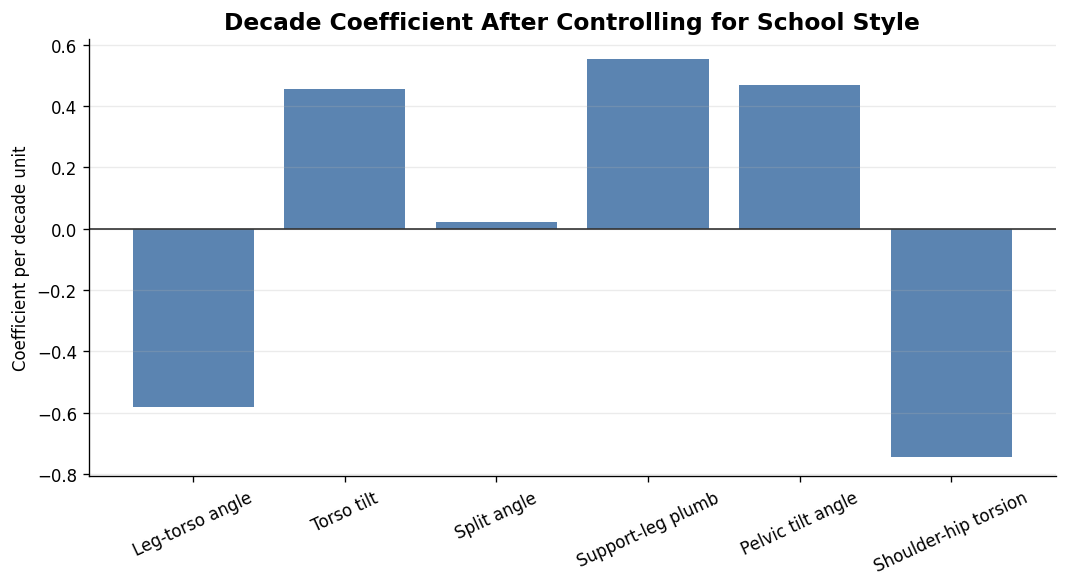

In [8]:
def ols_fit(y: np.ndarray, x: np.ndarray) -> dict:
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    pred = x @ beta
    resid = y - pred
    n, p = x.shape
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(1, n - p) if np.isfinite(r2) else np.nan
    sigma2 = ss_res / max(1, n - p)
    cov = sigma2 * np.linalg.pinv(x.T @ x)
    se = np.sqrt(np.diag(cov))
    t = beta / np.where(se == 0, np.nan, se)
    p_norm = np.array([math.erfc(abs(v) / math.sqrt(2)) if np.isfinite(v) else np.nan for v in t])
    return {"beta": beta, "r2": r2, "adj_r2": adj_r2, "p_norm": p_norm, "n": n}

regression_rows = []
interaction_rows = []

for metric in STYLE_ANALYSIS_FEATURES:
    model_data = df.dropna(subset=[metric, "decade", "school_style"])
    dummies = pd.get_dummies(model_data["school_style"].astype(str), drop_first=True, dtype=float)
    x = np.column_stack([np.ones(len(model_data)), model_data["decade"].to_numpy(dtype=float), dummies.to_numpy(dtype=float)])
    fit = ols_fit(model_data[metric].to_numpy(dtype=float), x)
    regression_rows.append({
        "metric": metric,
        "label": METRIC_LABELS[metric],
        "decade_coef": fit["beta"][1],
        "decade_pvalue_normal_approx": fit["p_norm"][1],
        "r_squared": fit["r2"],
        "adj_r_squared": fit["adj_r2"],
        "n": int(fit["n"]),
    })

    interactions = dummies.multiply(model_data["decade"].to_numpy(dtype=float), axis=0)
    x_int = np.column_stack([
        np.ones(len(model_data)),
        model_data["decade"].to_numpy(dtype=float),
        dummies.to_numpy(dtype=float),
        interactions.to_numpy(dtype=float),
    ])
    fit_int = ols_fit(model_data[metric].to_numpy(dtype=float), x_int)
    interaction_rows.append({
        "metric": metric,
        "label": METRIC_LABELS[metric],
        "r_squared": fit_int["r2"],
        "adj_r_squared": fit_int["adj_r2"],
        "n": int(fit_int["n"]),
    })

regression_df = pd.DataFrame(regression_rows)
interaction_df = pd.DataFrame(interaction_rows)
regression_df.to_csv(OUTPUT_DIR / "regression_decade_plus_style.csv", index=False)
interaction_df.to_csv(OUTPUT_DIR / "regression_decade_style_interaction.csv", index=False)

display(regression_df.round(4))
display(interaction_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(regression_df["label"], regression_df["decade_coef"], color="#5b84b1")
ax.axhline(0, color="#333333", linewidth=1)
ax.set_title("Decade Coefficient After Controlling for School Style", fontsize=14, fontweight="bold")
ax.set_ylabel("Coefficient per decade unit")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "regression_decade_coefficients.png", bbox_inches="tight")
plt.show()

## 8. Geometry Variance vs School-style Diversity

This compares whether decades with more diverse school-style representation also show more varied arabesque geometry.

,geometry_variance,style_entropy,pearson_r
decade,,,
2010,10.351,1.241,1.0
2020,10.962,1.322,1.0


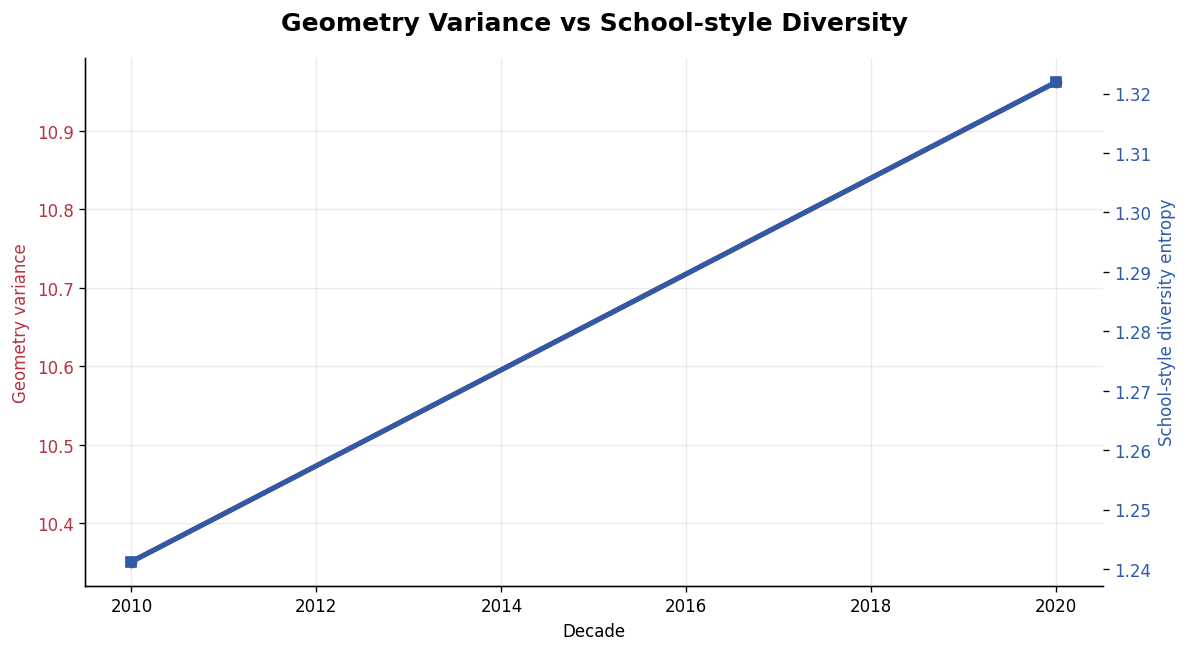

In [9]:
geometry_variance = df.groupby("decade", observed=True)[GEOMETRY_FEATURES].std().mean(axis=1).rename("geometry_variance")

style_by_decade = df.groupby(["decade", "school_style"], observed=True).size().unstack(fill_value=0)
style_proportions = style_by_decade.div(style_by_decade.sum(axis=1), axis=0)
style_entropy = style_proportions.apply(lambda row: float(-(row[row > 0] * np.log(row[row > 0])).sum()), axis=1).rename("style_entropy")

comparison = pd.concat([geometry_variance, style_entropy], axis=1).dropna()
if len(comparison) >= 2:
    comparison["pearson_r"] = float(np.corrcoef(comparison["geometry_variance"], comparison["style_entropy"])[0, 1])
else:
    comparison["pearson_r"] = np.nan

comparison.to_csv(OUTPUT_DIR / "geometry_variance_vs_style_diversity.csv")
display(comparison.round(3))

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.plot(comparison.index, comparison["geometry_variance"], color="#b33443", marker="o", linewidth=3, label="Geometry variance")
ax1.set_xlabel("Decade")
ax1.set_ylabel("Geometry variance", color="#b33443")
ax1.tick_params(axis="y", labelcolor="#b33443")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(comparison.index, comparison["style_entropy"], color="#2f5aa8", marker="s", linewidth=3, label="Style entropy")
ax2.set_ylabel("School-style diversity entropy", color="#2f5aa8")
ax2.tick_params(axis="y", labelcolor="#2f5aa8")

fig.suptitle("Geometry Variance vs School-style Diversity", fontsize=15, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "geometry_variance_vs_style_diversity.png", bbox_inches="tight")
plt.show()

## 9. Final Files

In [10]:
print(f"All outputs are in: {OUTPUT_DIR}")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

All outputs are in: D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main\arabesque_531_school_style_results
- filtered_school_style_rows.csv
- geometry_variance_vs_style_diversity.csv
- geometry_variance_vs_style_diversity.png
- inter_style_distance_by_decade.png
- inter_style_distances_by_decade.csv
- regression_decade_coefficients.png
- regression_decade_plus_style.csv
- regression_decade_style_interaction.csv
- school_style_boxplots_four_metrics.png
- school_style_boxplots_six_metrics.png
- school_style_median_iqr_four_metrics.png
- school_style_median_iqr_six_metrics.png
- school_style_representation_by_decade.png
- style_centroids_by_decade.csv
- style_metric_summary.csv
- style_representation_by_decade.csv
